In [4]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install subword-nmt

Note: you may need to restart the kernel to use updated packages.


In [5]:
import sys
import numpy as np
import torch
import torch.nn.functional as F

class Vocab:
    def __init__(self, tokens, bos="_BOS_", eos="_EOS_", unk='_UNK_'):
        """
        A special class that converts lines of tokens into matrices and backwards
        """
        assert all(tok in tokens for tok in (bos, eos, unk))
        self.tokens = tokens
        self.token_to_ix = {t:i for i, t in enumerate(tokens)}
        self.bos, self.eos, self.unk = bos, eos, unk
        self.bos_ix = self.token_to_ix[bos]
        self.eos_ix = self.token_to_ix[eos]
        self.unk_ix = self.token_to_ix[unk]

    def __len__(self):
        return len(self.tokens)

    @staticmethod
    def from_lines(lines, bos="_BOS_", eos="_EOS_", unk='_UNK_'):
        flat_lines = '\n'.join(list(lines)).split()
        tokens = sorted(set(flat_lines))
        tokens = [t for t in tokens if t not in (bos, eos, unk) and len(t)]
        tokens = [bos, eos, unk] + tokens
        return Vocab(tokens, bos, eos, unk)

    def tokenize(self, string):
        """converts string to a list of tokens"""
        tokens = [tok if tok in self.token_to_ix else self.unk
                  for tok in string.split()]
        return [self.bos] + tokens + [self.eos]

    def to_matrix(self, lines, dtype=torch.int64, max_len=None):
        """
        convert variable length token sequences into  fixed size matrix
        example usage:
        >>>print(to_matrix(words[:3],source_to_ix))
        [[15 22 21 28 27 13 -1 -1 -1 -1 -1]
         [30 21 15 15 21 14 28 27 13 -1 -1]
         [25 37 31 34 21 20 37 21 28 19 13]]
        """
        lines = list(map(self.tokenize, lines))
        max_len = max_len or max(map(len, lines))

        matrix = torch.full((len(lines), max_len), self.eos_ix, dtype=dtype)
        for i, seq in enumerate(lines):
            row_ix = list(map(self.token_to_ix.get, seq))[:max_len]
            matrix[i, :len(row_ix)] = torch.as_tensor(row_ix)

        return matrix

    def to_lines(self, matrix, crop=True):
        """
        Convert matrix of token ids into strings
        :param matrix: matrix of tokens of int32, shape=[batch,time]
        :param crop: if True, crops BOS and EOS from line
        :return:
        """
        lines = []
        for line_ix in map(list,matrix):
            if crop:
                if line_ix[0] == self.bos_ix:
                    line_ix = line_ix[1:]
                if self.eos_ix in line_ix:
                    line_ix = line_ix[:line_ix.index(self.eos_ix)]
            line = ' '.join(self.tokens[i] for i in line_ix)
            lines.append(line)
        return lines
    
    def compute_mask(self, input_ix):
        """ compute a boolean mask that equals "1" until first EOS (including that EOS) """
        return F.pad(torch.cumsum(input_ix == self.eos_ix, dim=-1)[..., :-1] < 1, pad=(1, 0, 0, 0), value=True)


In [11]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install subword_nmt

Note: you may need to restart the kernel to use updated packages.


In [2]:
from nltk.tokenize import WordPunctTokenizer

from subword_nmt.learn_bpe import learn_bpe

from subword_nmt.apply_bpe import BPE

tokenizer = WordPunctTokenizer()

def tokenize(x):
    return ' '.join(tokenizer.tokenize(x.lower()))



# split and tokenize the data
with open('train.en', 'w', encoding='utf-8') as f_src, \
     open('train.ru', 'w', encoding='utf-8') as f_dst, \
     open(r"D:\RStudio\nlp2\data.txt", encoding='utf-8') as f_in:

    for line in f_in:
        src_line, dst_line = line.strip().split('\t')
        f_src.write(tokenize(src_line) + '\n')
        f_dst.write(tokenize(dst_line) + '\n')


In [14]:
# build and apply bpe vocs
bpe = {}

for lang in ['en', 'ru']:
    # обучение bpe
    with open(f'./train.{lang}', encoding='utf-8') as f_train, \
         open(f'bpe_rules.{lang}', 'w', encoding='utf-8') as f_rules:
        learn_bpe(f_train, f_rules, num_symbols=8000)

    # применение bpe
    bpe[lang] = BPE(open(f'./bpe_rules.{lang}', encoding='utf-8'))

    with open(f'train.bpe.{lang}', 'w', encoding='utf-8') as f_out, \
         open(f'train.{lang}', encoding='utf-8') as f_in:
        for line in f_in:
            f_out.write(bpe[lang].process_line(line.strip()) + '\n')

100%|████████████████████████████████████████████████████████████████████████████| 8000/8000 [00:06<00:00, 1249.14it/s]


In [3]:
import numpy as np
from sklearn.model_selection import train_test_split

with open('./train.bpe.ru', encoding='utf-8') as f:
    data_inp = np.array(f.read().split('\n'))

with open('./train.bpe.en', encoding='utf-8') as f:
    data_out = np.array(f.read().split('\n'))

train_inp, dev_inp, train_out, dev_out = train_test_split(
    data_inp, data_out, test_size=3000, random_state=42
)

for i in range(3):
    print('inp:', train_inp[i])
    print('out:', train_out[i], end='\n\n')

inp: на территории обустроена бесплатная частная парковка .
out: free private parking is available on site .

inp: кроме того , в 5 минутах ходьбы работают многочисленные бары и рестораны .
out: guests can find many bars and restaurants within a 5 - minute walk .

inp: отель san mi@@ gu@@ el расположен в центре мор@@ ели@@ и , в 750 метрах от главной площади города и кафедрального собора .
out: hotel san miguel is located in central more@@ lia , 750 metres from the city ’ s main square and cathedral .



In [4]:
pip install Vocab

Note: you may need to restart the kernel to use updated packages.


In [9]:
import sys
import numpy as np
import torch
import torch.nn.functional as F

class Vocab:
    def __init__(self, tokens, bos="_BOS_", eos="_EOS_", unk='_UNK_'):
        """
        A special class that converts lines of tokens into matrices and backwards
        """
        assert all(tok in tokens for tok in (bos, eos, unk))
        self.tokens = tokens
        self.token_to_ix = {t:i for i, t in enumerate(tokens)}
        self.bos, self.eos, self.unk = bos, eos, unk
        self.bos_ix = self.token_to_ix[bos]
        self.eos_ix = self.token_to_ix[eos]
        self.unk_ix = self.token_to_ix[unk]

    def __len__(self):
        return len(self.tokens)

    @staticmethod
    def from_lines(lines, bos="_BOS_", eos="_EOS_", unk='_UNK_'):
        flat_lines = '\n'.join(list(lines)).split()
        tokens = sorted(set(flat_lines))
        tokens = [t for t in tokens if t not in (bos, eos, unk) and len(t)]
        tokens = [bos, eos, unk] + tokens
        return Vocab(tokens, bos, eos, unk)

    def tokenize(self, string):
        """converts string to a list of tokens"""
        tokens = [tok if tok in self.token_to_ix else self.unk
                  for tok in string.split()]
        return [self.bos] + tokens + [self.eos]

    def to_matrix(self, lines, dtype=torch.int64, max_len=None):
        """
        convert variable length token sequences into  fixed size matrix
        example usage:
        >>>print(to_matrix(words[:3],source_to_ix))
        [[15 22 21 28 27 13 -1 -1 -1 -1 -1]
         [30 21 15 15 21 14 28 27 13 -1 -1]
         [25 37 31 34 21 20 37 21 28 19 13]]
        """
        lines = list(map(self.tokenize, lines))
        max_len = max_len or max(map(len, lines))

        matrix = torch.full((len(lines), max_len), self.eos_ix, dtype=dtype)
        for i, seq in enumerate(lines):
            row_ix = list(map(self.token_to_ix.get, seq))[:max_len]
            matrix[i, :len(row_ix)] = torch.as_tensor(row_ix)

        return matrix

    def to_lines(self, matrix, crop=True):
        """
        Convert matrix of token ids into strings
        :param matrix: matrix of tokens of int32, shape=[batch,time]
        :param crop: if True, crops BOS and EOS from line
        :return:
        """
        lines = []
        for line_ix in map(list,matrix):
            if crop:
                if line_ix[0] == self.bos_ix:
                    line_ix = line_ix[1:]
                if self.eos_ix in line_ix:
                    line_ix = line_ix[:line_ix.index(self.eos_ix)]
            line = ' '.join(self.tokens[i] for i in line_ix)
            lines.append(line)
        return lines
    
    def compute_mask(self, input_ix):
        """ compute a boolean mask that equals "1" until first EOS (including that EOS) """
        return F.pad(torch.cumsum(input_ix == self.eos_ix, dim=-1)[..., :-1] < 1, pad=(1, 0, 0, 0), value=True)

inp_voc = Vocab.from_lines(train_inp)
out_voc = Vocab.from_lines(train_out)

In [10]:
# Here's how you cast lines into ids and backwards.
batch_lines = sorted(train_inp, key=len)[5:10]
batch_ids = inp_voc.to_matrix(batch_lines)
batch_lines_restored = inp_voc.to_lines(batch_ids)

print("lines")
print(batch_lines)
print("\nwords to ids (0 = bos, 1 = eos):")
print(batch_ids)
print("\nback to words")
print(batch_lines_restored)

lines
[np.str_('гостевой дом r .'), np.str_('до афин — 20 км .'), np.str_('работает боулинг .'), np.str_('оборудован балкон .'), np.str_('подключен wi - fi .')]

words to ids (0 = bos, 1 = eos):
tensor([[   0, 2688, 2943, 1108,   29,    1,    1,    1],
        [   0, 2922, 1834, 8035,   59, 3800,   29,    1],
        [   0, 6030, 2083,   29,    1,    1,    1,    1],
        [   0, 4927, 1870,   29,    1,    1,    1,    1],
        [   0, 5549, 1453,   27,  592,   29,    1,    1]])

back to words
['гостевой дом r .', 'до афин — 20 км .', 'работает боулинг .', 'оборудован балкон .', 'подключен wi - fi .']


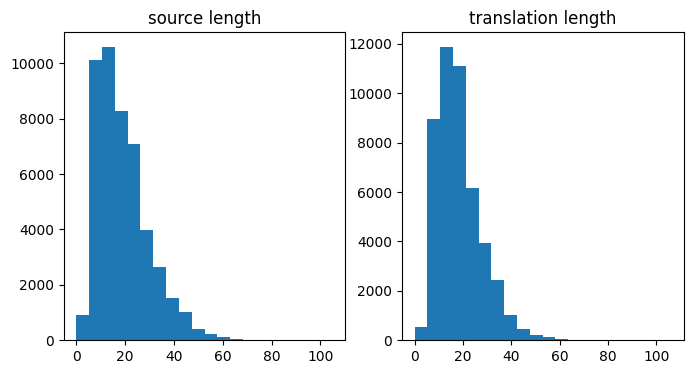

In [13]:
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(map(len, map(str.split, train_inp))), bins=20);

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(map(len, map(str.split, train_out))), bins=20);

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [15]:
class BasicModel(nn.Module):
    def __init__(self, inp_voc, out_voc, emb_size=64, hid_size=128):
        """
        A simple encoder-decoder seq2seq model
        """
        super().__init__() # initialize base class to track sub-layers, parameters, etc.

        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size

        self.emb_inp = nn.Embedding(len(inp_voc), emb_size)
        self.emb_out = nn.Embedding(len(out_voc), emb_size)
        self.enc0 = nn.GRU(emb_size, hid_size, batch_first=True)

        self.dec_start = nn.Linear(hid_size, hid_size)
        self.dec0 = nn.GRUCell(emb_size, hid_size)
        self.logits = nn.Linear(hid_size, len(out_voc))

    def forward(self, inp, out):
        """ Apply model in training mode """
        initial_state = self.encode(inp)
        return self.decode(initial_state, out)

    def encode(self, inp, **flags):
        """
        Takes symbolic input sequence, computes initial state
        :param inp: matrix of input tokens [batch, time]
        :returns: initial decoder state tensors, one or many
        """
        inp_emb = self.emb_inp(inp)
        batch_size = inp.shape[0]

        enc_seq, [last_state_but_not_really] = self.enc0(inp_emb)
        # enc_seq: [batch, time, hid_size], last_state: [batch, hid_size]

        # note: last_state is not _actually_ last because of padding, let's find the real last_state
        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]
        # ^-- shape: [batch_size, hid_size]

        dec_start = self.dec_start(last_state)
        return [dec_start]

    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Takes previous decoder state and tokens, returns new state and logits for next tokens
        :param prev_state: a list of previous decoder state tensors, same as returned by encode(...)
        :param prev_tokens: previous output tokens, an int vector of [batch_size]
        :return: a list of next decoder state tensors, a tensor of logits [batch, len(out_voc)]
        """
        prev_gru0_state = prev_state[0]

        prev_emb = self.emb_out(prev_tokens)                   # [batch, emb_size]
        new_gru0_state = self.dec0(prev_emb, prev_gru0_state)  # [batch, hid_size]
        output_logits = self.logits(new_gru0_state)            # [batch, |V_out|]

        new_dec_state = [new_gru0_state]

        return new_dec_state, output_logits

    def decode(self, initial_state, out_tokens, **flags):
        """ Iterate over reference tokens (out_tokens) with decode_step """
        batch_size = out_tokens.shape[0]
        state = initial_state

        # initial logits: always predict BOS
        onehot_bos = F.one_hot(torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64),
                               num_classes=len(self.out_voc)).to(device=out_tokens.device)
        first_logits = torch.log(onehot_bos.to(torch.float32) + 1e-9)

        logits_sequence = [first_logits]
        for i in range(out_tokens.shape[1] - 1):
            state, logits = self.decode_step(state, out_tokens[:, i])
            logits_sequence.append(logits)
        return torch.stack(logits_sequence, dim=1)

    def decode_inference(self, initial_state, max_len=100, **flags):
        """ Generate translations from model (greedy version) """
        batch_size, device_ = len(initial_state[0]), initial_state[0].device
        state = initial_state
        outputs = [torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64,
                              device=device_)]
        all_states = [initial_state]

        for i in range(max_len):
            state, logits = self.decode_step(state, outputs[-1])
            outputs.append(logits.argmax(dim=-1))
            all_states.append(state)

        return torch.stack(outputs, dim=1), all_states

    def translate_lines(self, inp_lines, **kwargs):
        inp = self.inp_voc.to_matrix(inp_lines).to(device)
        initial_state = self.encode(inp)
        out_ids, states = self.decode_inference(initial_state, **kwargs)
        return self.out_voc.to_lines(out_ids.cpu().numpy()), states

In [16]:
# debugging area
model = BasicModel(inp_voc, out_voc).to(device)

dummy_inp_tokens = inp_voc.to_matrix(sorted(train_inp, key=len)[5:10]).to(device)
dummy_out_tokens = out_voc.to_matrix(sorted(train_out, key=len)[5:10]).to(device)

h0 = model.encode(dummy_inp_tokens)
h1, logits1 = model.decode_step(h0, torch.arange(len(dummy_inp_tokens), device=device))

assert isinstance(h1, list) and len(h1) == len(h0)
assert h1[0].shape == h0[0].shape and not torch.allclose(h1[0], h0[0])
assert logits1.shape == (len(dummy_inp_tokens), len(out_voc))

logits_seq = model.decode(h0, dummy_out_tokens)
assert logits_seq.shape == (dummy_out_tokens.shape[0], dummy_out_tokens.shape[1], len(out_voc))

# full forward
logits_seq2 = model(dummy_inp_tokens, dummy_out_tokens)
assert logits_seq2.shape == logits_seq.shape

In [17]:
print("Source:")
print('\n'.join([line for line in train_inp[:3]]))
dummy_translations, dummy_states = model.translate_lines(train_inp[:3], max_len=25)

print("\nTranslations without training:")
print('\n'.join([line for line in dummy_translations]))

Source:
на территории обустроена бесплатная частная парковка .
кроме того , в 5 минутах ходьбы работают многочисленные бары и рестораны .
отель san mi@@ gu@@ el расположен в центре мор@@ ели@@ и , в 750 метрах от главной площади города и кафедрального собора .

Translations without training:
vacation crystal bar marks ant trams sun@@ te motor bat@@ rambl@@ attan ade@@ mission eting los 53 excellent for@@ naya tatami alternativ@@ thermal bar dar@@
riva vista navi@@ azul new separ@@ riva 300 brit@@ inclu@@ xi active 19@@ ning hob centr@@ karon karon anbul antalya bask@@ juan wyndham business new
riva vista navi@@ azul new separ@@ riva 300 brit@@ inclu@@ xi active 19@@ ning hob centr@@ karon karon anbul antalya bask@@ juan wyndham business new


In [18]:
def compute_loss(model, inp, out, **flags):
    """
    Compute loss (float32 scalar) as in the formula above
    :param inp: input tokens matrix, int32[batch, time]
    :param out: reference tokens matrix, int32[batch, time]
    
    In order to pass the tests, your function should
    * include loss at first EOS but not the subsequent ones
    * divide sum of losses by a sum of input lengths (use voc.compute_mask)
    """
    mask = model.out_voc.compute_mask(out) # [batch_size, out_len]
    targets_1hot = F.one_hot(out, len(model.out_voc)).to(torch.float32)
    
    # outputs of the model, [batch_size, out_len, num_tokens]
    logits_seq = model(inp, out)

    # log-probabilities of all tokens at all steps, [batch_size, out_len, num_tokens]
    logprobs_seq = F.log_softmax(logits_seq, dim=-1)
   
    # log-probabilities of correct outputs, [batch_size, out_len]
    logp_out = (logprobs_seq * targets_1hot).sum(dim=-1)
    # ^-- this will select the probability of the actual next token.
    # Note: you can compute loss more efficiently using using F.cross_entropy

    # average cross-entropy over tokens where mask == True
    mask = mask.to(torch.float32)
    loss = -(logp_out * mask).sum() / mask.sum()
    return loss # average loss, scalar

In [19]:
dummy_loss = compute_loss(model, dummy_inp_tokens, dummy_out_tokens)
print("Loss:", dummy_loss)
assert np.allclose(dummy_loss.item(), 7.5, rtol=0.1, atol=0.1), "We're sorry for your loss"

# test autograd
dummy_loss.backward()
for name, param in model.named_parameters():
    assert param.grad is not None and abs(param.grad.max()) != 0, f"Param {name} received no gradients"

Loss: tensor(7.5765, grad_fn=<DivBackward0>)


In [20]:
from nltk.translate.bleu_score import corpus_bleu
def compute_bleu(model, inp_lines, out_lines, bpe_sep='@@ ', **flags):
    """
    Estimates corpora-level BLEU score of model's translations given inp and reference out
    Note: if you're serious about reporting your results, use https://pypi.org/project/sacrebleu
    """
    with torch.no_grad():
        translations, _ = model.translate_lines(inp_lines, **flags)
        translations = [line.replace(bpe_sep, '') for line in translations]
        actual = [line.replace(bpe_sep, '') for line in out_lines]
        return corpus_bleu(
            [[ref.split()] for ref in actual],
            [trans.split() for trans in translations],
            smoothing_function=lambda precisions, **kw: [p + 1.0 / p.denominator for p in precisions]
            ) * 100

In [21]:
compute_bleu(model, dev_inp, dev_out)

0.002298235459048352

In [22]:
from IPython.display import clear_output
from tqdm import tqdm, trange
metrics = {'train_loss': [], 'dev_bleu': [] }

model = BasicModel(inp_voc, out_voc).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
batch_size = 32

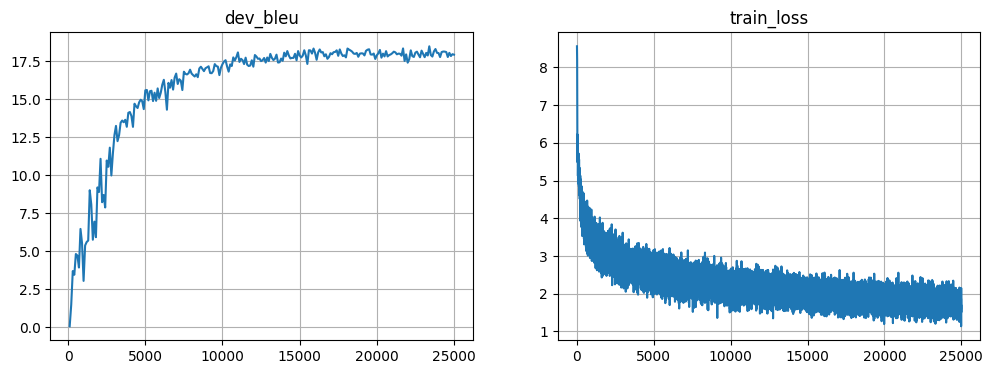

Mean loss=1.657


100%|██████████████████████████████████████████████████████████████████████████| 25000/25000 [1:22:00<00:00,  5.08it/s]


In [23]:
for _ in trange(25000):
    step = len(metrics['train_loss']) + 1
    batch_ix = np.random.randint(len(train_inp), size=batch_size)
    batch_inp = inp_voc.to_matrix(train_inp[batch_ix]).to(device)
    batch_out = out_voc.to_matrix(train_out[batch_ix]).to(device)

    opt.zero_grad()
    loss_t = compute_loss(model, batch_inp, batch_out)
    loss_t.backward()
    opt.step()

    metrics['train_loss'].append((step, loss_t.item()))

    if step % 100 == 0:
        metrics['dev_bleu'].append((step, compute_bleu(model, dev_inp, dev_out)))

        clear_output(True)
        plt.figure(figsize=(12,4))
        for i, (name, history) in enumerate(sorted(metrics.items())):
            plt.subplot(1, len(metrics), i + 1)
            plt.title(name)
            plt.plot(*zip(*history))
            plt.grid()
        plt.show()
        print("Mean loss=%.3f" % np.mean(metrics['train_loss'][-10:], axis=0)[1], flush=True)

# Note: it's okay if bleu oscillates up and down as long as it gets better on average over long term (e.g. 5k batches)


In [24]:
assert np.mean(metrics['dev_bleu'][-10:], axis=0)[1] > 15, "We kind of need a higher bleu BLEU from you. Kind of right now."

In [25]:
for inp_line, trans_line in zip(dev_inp[::500], model.translate_lines(dev_inp[::500])[0]):
    print(inp_line)
    print(trans_line)
    print()

в распоряжении гостей общая кухня и общая гостиная .
guests can benefit from shared kitchen facilities and shared lounge .

кроме того , предоставляется прокат велосипедов , услуги трансфера и бесплатная парковка .
bicycle rental , car rental and bike rental can be arranged .

расстояние до города ки@@ сси@@ м@@ ми составляет 26 км .
ka@@ storia town is 10 km away .

апартаменты в пент@@ хаусе с общим открытым бассейном , садом , кондиционером и террасой для загара расположены в 5 минутах ходьбы от пляжа на курорте ка@@ бо - рой .
located in a quiet , alan@@ - use barbecue facilities , a restaurant and a sun terrace , apartment on offers a garden and a terrace .

апартаменты mo@@ s@@ co@@ w point - loft red square находятся в москве , в 200 метрах от большого театра .
the lively dio@@ mon@@ o@@ met@@ ak vintage tur@@ y@@ ran@@ i is a 2 - minute walk from the cathedral of saint - tropez .

в вашем распоряжении собственная ванная комната с душем и полотенцами .
featuring a shower , priva

In [26]:
class DotProductAttentionLayer(nn.Module):
    def __init__(self, name, enc_size, dec_size, hid_size):
        """
        Scaled dot-product attention with projections
        :param enc_size: num units in encoder state
        :param dec_size: num units in decoder state
        :param hid_size: dimension of query/key space (d_k)
        """
        super().__init__()
        self.name = name
        self.enc_size = enc_size
        self.dec_size = dec_size
        self.hid_size = hid_size

        # Define projection layers
        # W_q, W_k, W_v project decoder states into query, key, value
        self.W_q = nn.Linear(dec_size, hid_size, bias=False)
        self.W_k = nn.Linear(enc_size, hid_size, bias=False)
        self.W_v = nn.Linear(enc_size, self.enc_size, bias=False)

    def forward(self, enc, dec, inp_mask):
        """
        Compute attention response and weights
        :param enc: encoder sequence [batch_size, ninp, enc_size]
        :param dec: decoder state [batch_size, dec_size]
        :param inp_mask: mask [batch_size, ninp] (0 = padding)
        :returns: attn [batch_size, enc_size], probs [batch_size, ninp]
        """

        # Compute Q, K, V projections
        Q = self.W_q(dec)          # [batch, hid_size]
        K = self.W_k(enc)          # [batch, ninp, hid_size]
        V = self.W_v(enc)          # [batch, ninp, enc_size]

        # Compute logits as scaled dot product QK^T, do not forget 1 / d
        # Hint: You may want to expand Q to shape [batch_size, 1, hid_size]
        Q_exp = Q.unsqueeze(1)     # [batch, 1, hid_size]
        logits = torch.bmm(Q_exp, K.transpose(1, 2)).squeeze(1)  # [batch, ninp]
        logits = logits / np.sqrt(self.hid_size)

        # Apply mask - if mask is 0, logits should be -inf or -1e9
        # You may need torch.where
        mask_zero = (inp_mask == 0)
        logits = logits.masked_fill(mask_zero, -1e9)

        # Softmax
        probs = F.softmax(logits, dim=-1)  # [batch, ninp]

        # Compute attention response
        attn = torch.bmm(probs.unsqueeze(1), V).squeeze(1)  # [batch, enc_size]

        return attn, probs

In [27]:
class AttentiveModel(BasicModel):
    def __init__(self, name, inp_voc, out_voc,
                 emb_size=64, hid_size=128, attn_size=128):
        """ Translation model that uses attention. See instructions above. """
        nn.Module.__init__(self)  # initialize base class to track sub-layers, trainable variables, etc.
        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size
        self.name = name

        self.emb_inp = nn.Embedding(len(inp_voc), emb_size)
        self.emb_out = nn.Embedding(len(out_voc), emb_size)

        self.enc0 = nn.GRU(emb_size, hid_size, batch_first=True)

        # decoder gets [emb_out; attn_context]
        self.dec0 = nn.GRUCell(emb_size + hid_size, hid_size)

        self.dec_start = nn.Linear(hid_size, hid_size)

        self.attn_layer = DotProductAttentionLayer(
            name=f"{name}_attn",
            enc_size=hid_size,
            dec_size=hid_size,
            hid_size=attn_size,
        )

        self.logits = nn.Linear(hid_size, len(out_voc))

    def encode(self, inp, **flags):
        """
        Takes symbolic input sequence, computes initial state
        :param inp: matrix of input tokens [batch, time]
        :return: a list of initial decoder state tensors
        """
        # encode input sequence, create initial decoder states
        inp_emb = self.emb_inp(inp)                          # [batch, time, emb_size]
        enc_seq, [last_state_raw] = self.enc0(inp_emb)       # [batch, time, hid_size]

        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]  # [batch, hid_size]

        dec_start = self.dec_start(last_state)               # [batch, hid_size]

        # attention mask: 1 = token, 0 = padding/EOS
        inp_mask = (inp != self.inp_voc.eos_ix).to(torch.float32)  # [batch, time]

        # apply attention layer from initial decoder hidden state
        first_attn, first_attn_probas = self.attn_layer(enc_seq, dec_start, inp_mask)

        # Build first state:
        # [decoder_hidden, encoder_sequence, encoder_mask, attention_context, attention_probs]
        first_state = [dec_start, enc_seq, inp_mask, first_attn, first_attn_probas]
        return first_state

    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Takes previous decoder state and tokens, returns new state and logits for next tokens
        :param prev_state: a list of previous decoder state tensors
        :param prev_tokens: previous output tokens, an int vector of [batch_size]
        :return: a list of next decoder state tensors, a tensor of logits [batch, n_tokens]
        """
        dec_state, enc_seq, inp_mask, prev_attn, prev_attn_probs = prev_state

        prev_emb = self.emb_out(prev_tokens)  # [batch, emb_size]
        dec_input = torch.cat([prev_emb, prev_attn], dim=-1)  # [batch, emb_size + hid_size]

        new_dec_state = self.dec0(dec_input, dec_state)       # [batch, hid_size]

        new_attn, new_attn_probs = self.attn_layer(enc_seq, new_dec_state, inp_mask)

        output_logits = self.logits(new_dec_state)            # [batch, n_tokens]

        new_dec_state = [new_dec_state, enc_seq, inp_mask, new_attn, new_attn_probs]
        return [new_dec_state, output_logits]

In [28]:
# create AttentiveModel and training utilities
model = AttentiveModel("attentive", inp_voc, out_voc).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
batch_size = 32

metrics_attn = {'train_loss': [], 'dev_bleu': []}

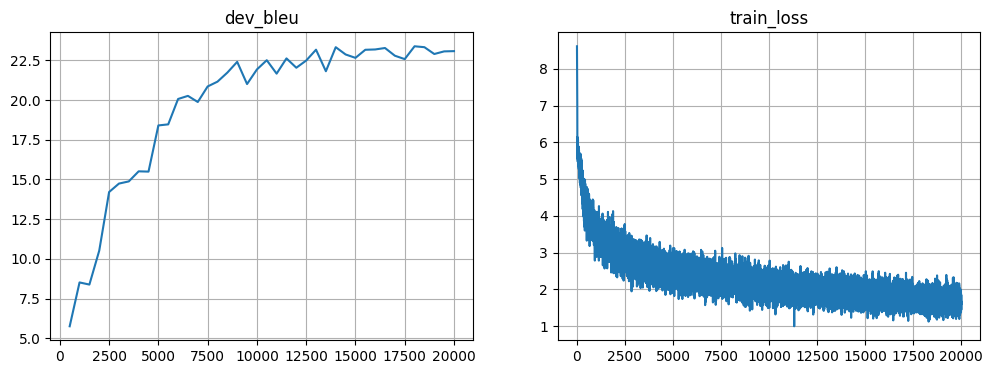

Mean loss=1.668


100%|██████████████████████████████████████████████████████████████████████████| 20000/20000 [2:01:31<00:00,  2.74it/s]


In [29]:
# training loop for AttentiveModel
for _ in trange(20000):
    step = len(metrics_attn['train_loss']) + 1
    batch_ix = np.random.randint(len(train_inp), size=batch_size)
    batch_inp = inp_voc.to_matrix(train_inp[batch_ix]).to(device)
    batch_out = out_voc.to_matrix(train_out[batch_ix]).to(device)

    opt.zero_grad()
    loss_t = compute_loss(model, batch_inp, batch_out)
    loss_t.backward()
    opt.step()

    metrics_attn['train_loss'].append((step, loss_t.item()))

    if step % 500 == 0:
        dev_bleu = compute_bleu(model, dev_inp, dev_out)
        metrics_attn['dev_bleu'].append((step, dev_bleu))

        clear_output(True)
        plt.figure(figsize=(12, 4))
        for i, (name, history) in enumerate(sorted(metrics_attn.items())):
            plt.subplot(1, len(metrics_attn), i + 1)
            plt.title(name)
            plt.plot(*zip(*history))
            plt.grid()
        plt.show()
        print("Mean loss=%.3f" % np.mean(metrics_attn['train_loss'][-10:], axis=0)[1], flush=True)

In [30]:
# measure final BLEU
final_bleu = compute_bleu(model, dev_inp, dev_out)
print("Final dev BLEU with attention:", final_bleu)

Final dev BLEU with attention: 23.0827059100021


In [32]:
pip install bokeh

  Using cached bokeh-3.8.1-py3-none-any.whl.metadata (10 kB)
Using cached bokeh-3.8.1-py3-none-any.whl (7.2 MB)

   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   ------------- -------------------------- 1/3 [narwhals]
   -------------------------- ------------- 2/3 [bokeh]
   -------------------------- ------------- 2/3 [bokeh]
   -------------------------- ------------- 2/3 [bokeh]
   -------------------------- ------------- 2/3 [bokeh]
   -------------------------- ------------- 2/3 [bokeh]
   -------------------------- ------------- 2/3 [bokeh]
   -------------------------- ------------- 2/3 [bokeh]
   -------------------------- ------------- 2/3 [bokeh]
   -------------------------- ------------- 2/3 [bokeh]
   -------------------------- ------------- 2/3 [bokeh]
   -------------------------- ------------- 2/3 [bokeh]
   ---------------------------------------- 3/3 [bokeh]

Note: you may need to restart the ker

In [33]:
import bokeh.plotting as pl
import bokeh.models as bm
from bokeh.io import output_notebook, show
output_notebook()



def draw_attention(inp_line, translation, probs):
    """ An intentionally ambiguous function to visualize attention weights """
    inp_tokens = inp_voc.tokenize(inp_line)
    trans_tokens = out_voc.tokenize(translation)
    probs = probs[:len(trans_tokens), :len(inp_tokens)]

    fig = pl.figure(x_range=(0, len(inp_tokens)), y_range=(0, len(trans_tokens)),
                    x_axis_type=None, y_axis_type=None, tools=[])
    fig.image([probs[::-1]], 0, 0, len(inp_tokens), len(trans_tokens))

    fig.add_layout(bm.LinearAxis(axis_label='source tokens'), 'above')
    fig.xaxis.ticker = np.arange(len(inp_tokens)) + 0.5
    fig.xaxis.major_label_overrides = dict(zip(np.arange(len(inp_tokens)) + 0.5, inp_tokens))
    fig.xaxis.major_label_orientation = 45

    fig.add_layout(bm.LinearAxis(axis_label='translation tokens'), 'left')
    fig.yaxis.ticker = np.arange(len(trans_tokens)) + 0.5
    fig.yaxis.major_label_overrides = dict(zip(np.arange(len(trans_tokens)) + 0.5, trans_tokens[::-1]))
    show(fig)

Loading BokehJS ...

In [34]:
print("Source:")
print('\n'.join([line for line in train_inp[:3]]))
trans, states = model.translate_lines(train_inp[:3])

print("\nTranslations without training:")
print('\n'.join([line for line in trans]))

Source:
на территории обустроена бесплатная частная парковка .
кроме того , в 5 минутах ходьбы работают многочисленные бары и рестораны .
отель san mi@@ gu@@ el расположен в центре мор@@ ели@@ и , в 750 метрах от главной площади города и кафедрального собора .

Translations without training:
free private parking is available on site .
many bars and restaurants can be found within a 5 - minute walk .
hotel san miguel is located in the vibrant diocletian , 750 metres from piazza and cathedral .


In [36]:
inp = dev_inp[::500]

trans, states = model.translate_lines(inp)

# select attention probs from model state (you may need to change this for your custom model)
# attention_probs below must have shape [batch_size, translation_length, input_length], extracted from states
# e.g. if attention probs are at the end of each state, use np.stack([state[-1] for state in states], axis=1)
attention_probs = np.stack([state[-1].detach().cpu().numpy() for state in states], axis=0)

In [37]:
for i in range(5):
    draw_attention(inp[i], trans[i], attention_probs[:, i])
# Does it look fine already? don't forget to save images for anytask!